# FLOWER VLA in our CALVIN env

This mirrors `calvin_experiments/env_playground.ipynb`, but the policy is FLOWER and the environment is this repo's robomimic-style CALVIN env. The adapter in `flower_our_env_rollout.py` maps `third_person` / `eye_in_hand` images back to what FLOWER expects and leaves the CALVIN env internals untouched.

In [8]:
from pathlib import Path
import importlib
import json
import os
import sys

import numpy as np

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")
os.environ.setdefault("HF_HOME", str(Path.home() / ".cache/huggingface"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

def find_repo_root(start=None):
    start_path = Path.cwd() if start is None else Path(start)
    for path in (start_path, *start_path.parents):
        if (path / "calvin_experiments" / "calvin_rollout_utils.py").exists():
            return path
    raise FileNotFoundError(f"Could not find repo root from {start_path}")

REPO_ROOT = find_repo_root()
FLOWER_ROOT = REPO_ROOT / "flower_vla_calvin"
BASELINES_ROOT = REPO_ROOT / "calvin_experiments" / "paper_stls" / "baselines"

for path in [
    REPO_ROOT,
    REPO_ROOT / "robomimic",
    REPO_ROOT / "calvin" / "calvin_env",
    REPO_ROOT / "calvin_experiments",
    FLOWER_ROOT,
    BASELINES_ROOT,
]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils

import calvin_experiments.calvin_rollout_utils as CalvinRolloutUtils
import flower_our_env_rollout as FlowerOurEnv

CalvinRolloutUtils = importlib.reload(CalvinRolloutUtils)
FlowerOurEnv = importlib.reload(FlowerOurEnv)

from calvin_experiments.calvin_rollout_utils import (
    articulated_binaries_from_start_state,
    capture_scene_snapshot,
    close_env_quietly,
    fixed_scene_robot_from_config,
    load_fresh_env_from_checkpoint,
    load_json_config,
    render_visual_camera,
    reset_env_to_scene_robot,
    run_folder_name,
    save_rollout_artifacts,
    seed_everything,
)

print(f"repo: {REPO_ROOT}")
print(f"flower: {FLOWER_ROOT}")

repo: /home/moritz/src/guided-diffusion
flower: /home/moritz/src/guided-diffusion/flower_vla_calvin


In [9]:
# Policy and env loading. Rollout knobs live in the call cell below.
FLOWER_CHECKPOINT = FlowerOurEnv.DEFAULT_FLOWER_CHECKPOINT
ENV_CHECKPOINT = FlowerOurEnv.DEFAULT_ENV_CHECKPOINT
DEVICE_NAME = "auto"  # use "cuda:0" outside the sandbox if auto cannot see CUDA

device = FlowerOurEnv.resolve_device(DEVICE_NAME)
ckpt_dict = FileUtils.maybe_dict_from_checkpoint(ckpt_path=str(ENV_CHECKPOINT))
flower_model = FlowerOurEnv.load_flower_model(Path(FLOWER_CHECKPOINT), device)
flower_policy = FlowerOurEnv.FlowerPolicyAdapter(flower_model, device=device)

print(f"FLOWER checkpoint: {FLOWER_CHECKPOINT}")
print(f"Env checkpoint:    {ENV_CHECKPOINT}")
print(f"Device:            {device}")

Detected HuggingFace format
Loading config from: /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/flower_calvin_d/config.yaml
Loading model from /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/flower_calvin_d/model.safetensors
Loading Florence-2 from microsoft/Florence-2-large
Loading pretrained weights from /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/flower_calvin_d/model.safetensors...
Loaded safetensors file
Pretrained weights loaded with the following issues:
  ⚠️ Missing keys (not found in checkpoint, using default init): 2
    ['vlm.language_model.final_logits_bias', 'vlm.language_model.model.shared.weight'] ...
  ⚠️ Unexpected keys (ignored): 2
    ['vlm.language_final_logits_bias', 'vlm.language_shared.weight'] ...
Finished loading model /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/flower_calvin_d/model.safetensors
FLOWER checkpoint: /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/fl

In [10]:
def plot_flower_rollouts_time_gradient(
    rollout_summaries,
    title=None,
    save_path=None,
    display_inline=True,
    cmap_name="plasma",
):
    """Draw top-down EEF traces colored by rollout step and mark behavior events."""
    if not rollout_summaries:
        print("Run rollout generation first; it writes trace .npz files for plotting.")
        return

    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    first_item = rollout_summaries[0]
    scene_snapshot = load_json_config(first_item["scene_snapshot"])
    rollouts = []
    for item in rollout_summaries:
        trace = np.load(item["trace"])
        rollouts.append(
            {
                "eef_xy": np.asarray(trace["eef_xy"], dtype=np.float32),
                "seed": item.get("seed", item.get("rollout", "?")),
                "behavior": item.get("behavior", "none"),
                "detected_behaviors": item.get("detected_behaviors", []),
                "behavior_steps": item.get("behavior_steps", {}),
            }
        )

    paths = [r["eef_xy"] for r in rollouts]
    max_step = max(max(1, len(path) - 1) for path in paths)
    norm = Normalize(vmin=0, vmax=max_step)
    cmap = plt.get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#fbf7ef")
    CalvinRolloutUtils.draw_scene_snapshot(ax, scene_snapshot)

    for rollout, xy in zip(rollouts, paths):
        if len(xy) >= 2:
            segments = np.stack([xy[:-1], xy[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.3, alpha=0.84)
            lc.set_array(np.arange(len(segments), dtype=np.float32))
            ax.add_collection(lc)
        ax.scatter(xy[0, 0], xy[0, 1], c="white", s=46, edgecolors="black", linewidths=0.9, zorder=5)
        ax.scatter(xy[-1, 0], xy[-1, 1], c="black", s=42, edgecolors="white", linewidths=0.7, zorder=5)
        ax.text(xy[-1, 0] + 0.004, xy[-1, 1] + 0.004, f"s{rollout['seed']}", fontsize=8, color="black")

        for behavior, step in rollout["behavior_steps"].items():
            step = min(max(int(step), 0), len(xy) - 1)
            ax.scatter(
                xy[step, 0],
                xy[step, 1],
                marker="*",
                s=135,
                c=[cmap(norm(step))],
                edgecolors="black",
                linewidths=0.75,
                zorder=6,
            )
            ax.text(xy[step, 0] + 0.004, xy[step, 1] - 0.010, f"{behavior}@{step}", fontsize=7, color="black")

    all_xy = np.concatenate(paths, axis=0)
    xlim, ylim = CalvinRolloutUtils.scene_limits_from_snapshot(scene_snapshot, all_xy)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    if title is None:
        title = f"FLOWER top-down rollouts | {first_item['scene_config']} | {len(rollout_summaries)} trajectories"
    ax.set_title(title)
    ax.set_xlabel("world x [m]")
    ax.set_ylabel("world y [m]")
    ax.grid(alpha=0.3)

    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("rollout step")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)

    if display_inline:
        from io import BytesIO
        from IPython.display import Image, display

        png = BytesIO()
        fig.savefig(png, format="png", dpi=100, bbox_inches="tight")
        plt.close(fig)
        display(Image(data=png.getvalue()))
    else:
        plt.close(fig)

In [11]:
def run_flower_playground(
    flower_policy,
    ckpt_dict,
    instruction,
    scene_config_path,
    video_config_path,
    output_root,
    horizon=100,
    num_rollouts=1,
    seed=0,
    fps=30,
    expected_behaviors=None,
):
    """Roll out FLOWER with the same artifact flow as env_playground.ipynb."""
    scene_config_path = Path(scene_config_path)
    video_config_path = Path(video_config_path)
    output_root = Path(output_root)
    expected_behaviors = list(dict.fromkeys(expected_behaviors or []))

    video_cfg = load_json_config(video_config_path)
    scene_cfg_json = load_json_config(scene_config_path)
    scene_name = scene_cfg_json["name"]
    output_dir = output_root / run_folder_name(
        "flower_vla",
        f"scene_{scene_name}",
        f"rollouts{num_rollouts}",
        f"horizon{horizon}",
        f"seed{seed}",
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    summaries = []
    env = None
    try:
        seed_everything(seed)
        for rollout_idx in range(int(num_rollouts)):
            rollout_seed = None if seed is None else int(seed) + rollout_idx
            env, base_env_state = load_fresh_env_from_checkpoint(
                ckpt_dict,
                seed=rollout_seed,
                existing_env=env,
                suppress_output=True,
            )
            fixed_scene, fixed_robot, scene_cfg = fixed_scene_robot_from_config(base_env_state, scene_config_path)
            seed_everything(rollout_seed)
            flower_policy.reset(instruction)
            obs = reset_env_to_scene_robot(env, fixed_scene, fixed_robot)

            scene_snapshot = capture_scene_snapshot(env)
            start_state = env.get_state()
            start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
            binaries = articulated_binaries_from_start_state(start_scene)

            frames = [render_visual_camera(env, video_cfg)]
            actions, rewards, dones = [], [], []
            scene_states = [start_scene.copy()]
            robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
            eef_xy = [robot_states[-1][:2].copy()]
            detected_behavior = "none"
            detected_step = -1
            detected_behaviors = []
            behavior_steps = {}
            termination_reason = "horizon"

            for step in range(int(horizon)):
                action = flower_policy(obs)
                actions.append(action.copy())
                obs, reward, done, info = env.step(action.copy())
                state = env.get_state()
                scene = np.asarray(state["scene"], dtype=np.float32).copy()
                robot = np.asarray(state["robot"], dtype=np.float32).copy()

                rewards.append(float(reward))
                dones.append(bool(done))
                scene_states.append(scene)
                robot_states.append(robot)
                eef_xy.append(robot[:2].copy())
                frames.append(render_visual_camera(env, video_cfg))

                current_behaviors = FlowerOurEnv.detect_behaviors_from_state(start_scene, scene, robot[:3], binaries)
                for behavior in current_behaviors:
                    if behavior not in behavior_steps:
                        behavior_steps[behavior] = step + 1
                        detected_behaviors.append(behavior)
                if detected_step < 0 and detected_behaviors:
                    detected_behavior = detected_behaviors[0]
                    detected_step = behavior_steps[detected_behavior]
                if expected_behaviors and set(expected_behaviors).issubset(behavior_steps):
                    termination_reason = "expected_behaviors"
                    break
                if done:
                    termination_reason = "env_done"
                    break

            rollout = {
                "scene_config": scene_name,
                "seed": rollout_seed,
                "instruction": instruction,
                "behavior": detected_behavior,
                "behavior_step": detected_step,
                "detected_behaviors": detected_behaviors,
                "behavior_steps": behavior_steps,
                "expected_behaviors": expected_behaviors,
                "termination_step": len(actions),
                "termination_reason": termination_reason,
                "return": float(np.sum(rewards)),
                "actions": np.asarray(actions, dtype=np.float32),
                "rewards": np.asarray(rewards, dtype=np.float32),
                "dones": np.asarray(dones, dtype=bool),
                "scene_states": np.asarray(scene_states, dtype=np.float32),
                "robot_states": np.asarray(robot_states, dtype=np.float32),
                "eef_xy": np.asarray(eef_xy, dtype=np.float32),
                "scene_snapshot": scene_snapshot,
            }
            save_rollout_artifacts(rollout, frames, output_dir, f"rollout_{rollout_idx:03d}", video_cfg, fps=fps)
            summaries.append(
                {
                    "scene_config": scene_name,
                    "rollout": rollout_idx,
                    "seed": rollout_seed,
                    "instruction": instruction,
                    "behavior": detected_behavior,
                    "step": detected_step,
                    "detected_behaviors": detected_behaviors,
                    "behavior_steps": behavior_steps,
                    "expected_behaviors": expected_behaviors,
                    "termination_step": len(actions),
                    "termination_reason": termination_reason,
                    "video": str(rollout["video"]),
                    "trace": str(rollout["trace"]),
                    "scene_snapshot": str(rollout["scene_snapshot_path"]),
                }
            )
            print(
                f"rollout {rollout_idx:03d}: behavior={detected_behavior} "
                f"step={detected_step} detected={detected_behaviors} "
                f"termination={termination_reason} actions={len(actions)}"
            )
    finally:
        close_env_quietly(env)

    summary_path = output_dir / "flower_rollout_summary.json"
    with summary_path.open("w") as f:
        json.dump(summaries, f, indent=2)

    if summaries:
        plot_flower_rollouts_time_gradient(
            summaries,
            title=f"FLOWER VLA | {scene_name} | {instruction}",
            save_path=output_dir / "rollout_scene_overlay_all.png",
            display_inline=True,
        )
    print(f"Output: {output_dir}")
    print(f"Summary JSON: {summary_path}")
    return output_dir, summaries

ven = NVIDIA Corporation
ven = NVIDIA Corporation
rollout 000: behavior=drawer_open step=74 detected=['drawer_open'] termination=horizon actions=300
plot: /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/our_env_rollouts/flower_vla_scene_blocks_hidden_rollouts1_horizon300_seed0_07-05-26__00-42-38/rollout_scene_overlay_all.png


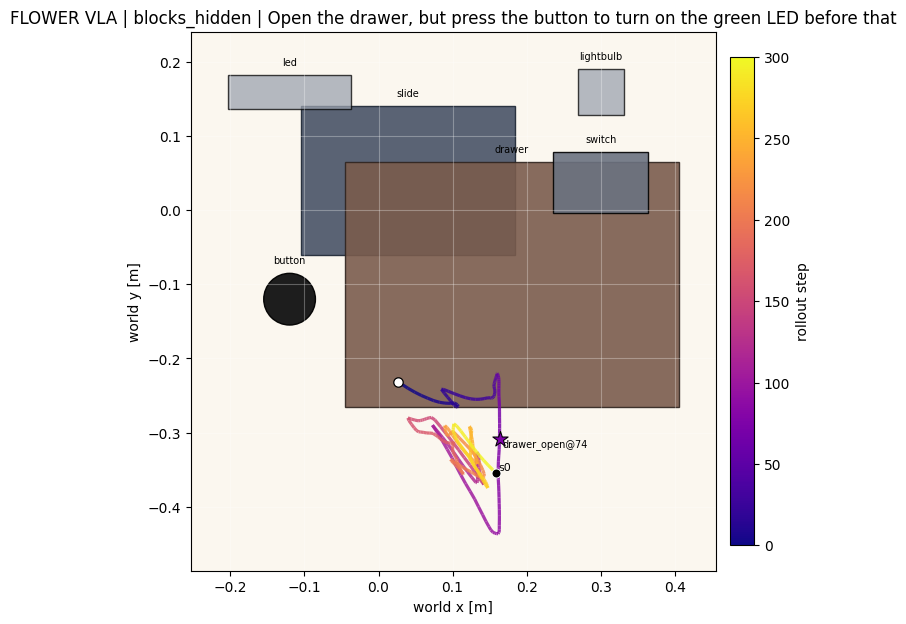

Output: /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/our_env_rollouts/flower_vla_scene_blocks_hidden_rollouts1_horizon300_seed0_07-05-26__00-42-38
Summary JSON: /home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/our_env_rollouts/flower_vla_scene_blocks_hidden_rollouts1_horizon300_seed0_07-05-26__00-42-38/flower_rollout_summary.json
disconnecting id -1 from server


In [21]:
# Rollout settings live here for quick notebook iteration.
INSTRUCTION = "Open the drawer, but press the button to turn on the green LED before that" # then use the switch to turn on the light bulb, then press the button again, then push the sliding door to the left side, and finally close the drawer."
SCENE_CONFIG_PATH = FlowerOurEnv.DEFAULT_SCENE_CONFIG
VISUALIZATION_CONFIG_PATH = FlowerOurEnv.DEFAULT_VIDEO_CONFIG
OUTPUT_ROOT = FlowerOurEnv.DEFAULT_OUTPUT_ROOT
HORIZON = 300
NUM_ROLLOUTS = 1
GLOBAL_SEED = 0
FPS = 30

# Empty list means run until horizon/env_done. Non-empty list stops once all listed behaviors happened.
EXPECTED_BEHAVIORS = ["button_on", "drawer_open"] #, "switch_on", "button_pressed", "door_left", "drawer_closed"]

output_dir, policy_rollout_summaries = run_flower_playground(
    flower_policy=flower_policy,
    ckpt_dict=ckpt_dict,
    instruction=INSTRUCTION,
    scene_config_path=SCENE_CONFIG_PATH,
    video_config_path=VISUALIZATION_CONFIG_PATH,
    output_root=OUTPUT_ROOT,
    horizon=HORIZON,
    num_rollouts=NUM_ROLLOUTS,
    seed=GLOBAL_SEED,
    fps=FPS,
    expected_behaviors=EXPECTED_BEHAVIORS,
)

/home/moritz/src/guided-diffusion/outputs/calvin/baselines/flower/our_env_rollouts/flower_vla_scene_blocks_hidden_rollouts1_horizon100_seed0_07-05-26__00-04-48/rollout_000/blocks_hidden_rollout_000_freiburg_style.mp4


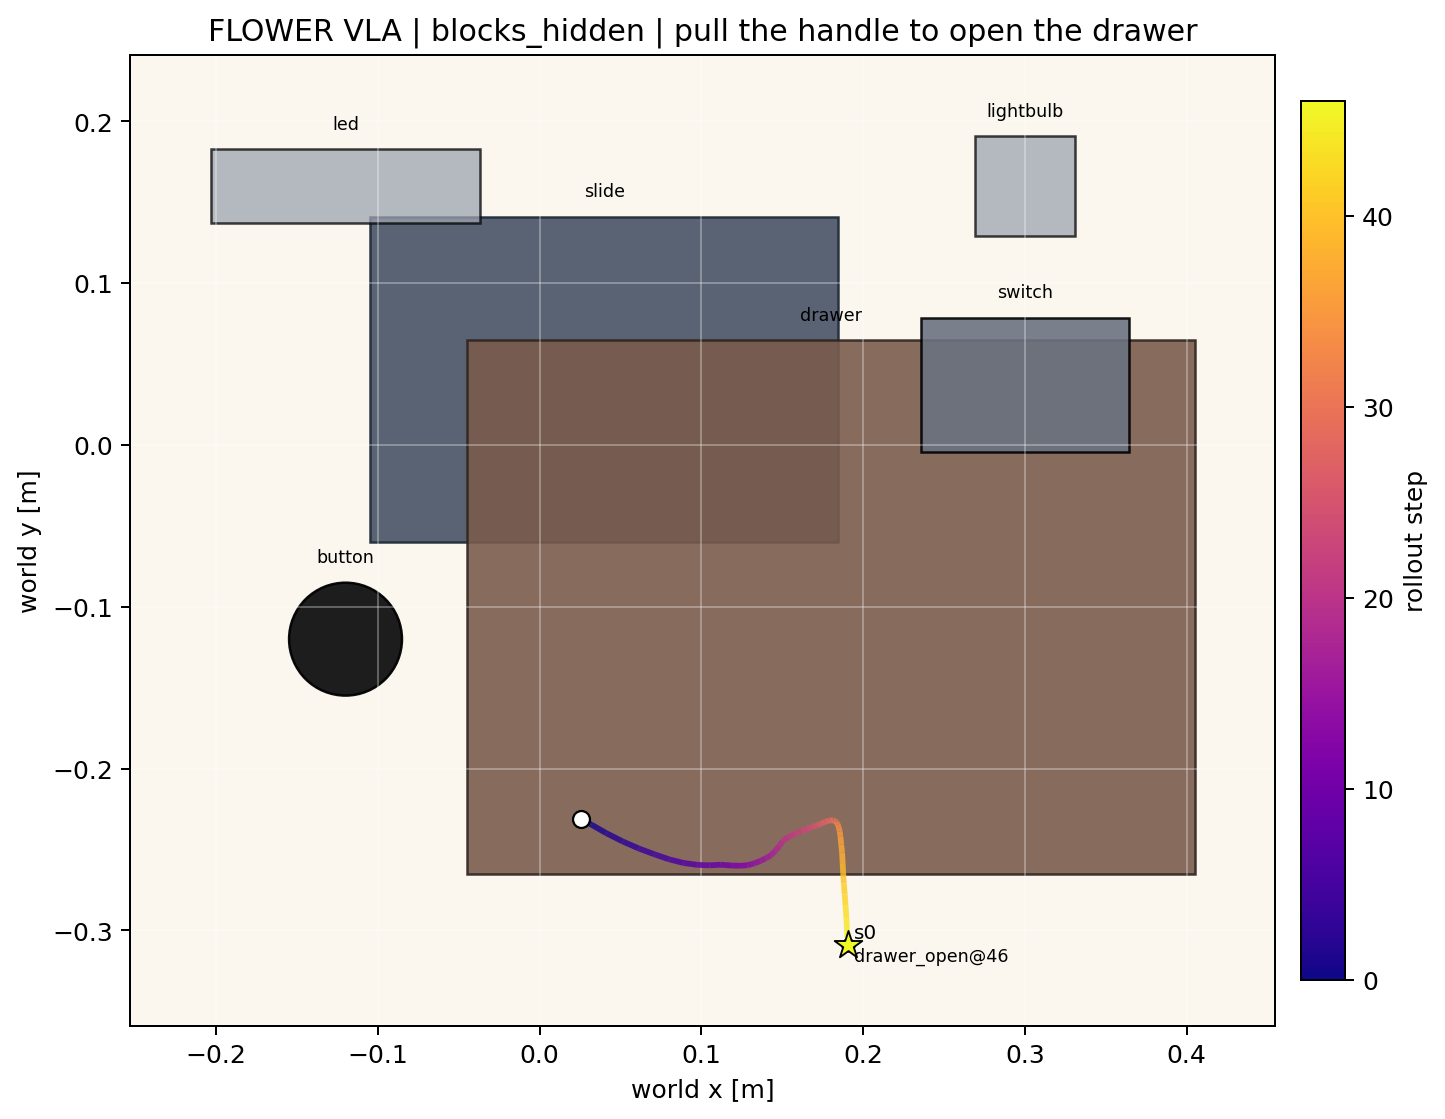

In [13]:
from IPython.display import Image, Video, display

if policy_rollout_summaries:
    video_path = Path(policy_rollout_summaries[0]["video"])
    plot_path = Path(output_dir) / "rollout_scene_overlay_all.png"
    print(video_path)
    display(Video(str(video_path), embed=False))
    if plot_path.exists():
        display(Image(filename=str(plot_path)))